NAME : PAN TIYA R.

ENROLLMENT NO. : 23SOECE11026 

ROLL NO :20 

DIVISION : A

**Exercise 1: Implement kmeans clustering**

Load Iris dataset using sklearn.

Apply K-Means clustering with a fixed number of clusters (k=3).

Assign cluster labels to each data point.

Use the Elbow Method to determine the optimal number of clusters.

Plot inertia vs number of clusters to identify the elbow point.

Compare clustering results with and without the Elbow Method.

Implement K-Means clustering using the pyclustering library.

Analyze clusters formed and compare with sklearn results.


k-means withot elbow method

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [2]:
# 1.Load Iris dataset using sklearn.
iris=load_iris()
df=pd.DataFrame(iris.data,columns=iris.feature_names)

In [3]:
# Selecting only two features for visualization
X=df[['sepal length (cm)', 'sepal width (cm)']].values

In [4]:
#Standardize the features
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [5]:
# kmeans
kmeans=KMeans(n_clusters=5,init='k-means++',random_state=42)
y_kmeans=kmeans.fit_predict(X_scaled)

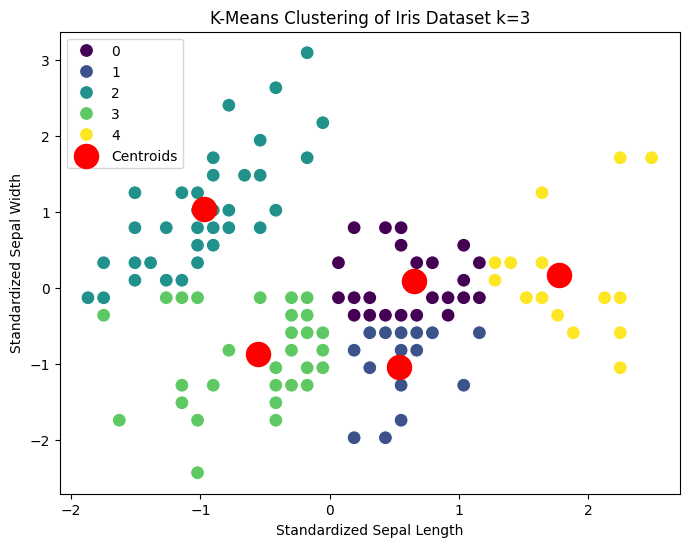

In [6]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_scaled[:,0],y=X_scaled[:,1],hue=y_kmeans,palette='viridis',s=100)
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s=300,c='red',label='Centroids')
plt.title('K-Means Clustering of Iris Dataset k=3')
plt.xlabel('Standardized Sepal Length')
plt.ylabel('Standardized Sepal Width')
plt.legend()
plt.show()

k-means clusturing Elbow method

the elbow method is a technique used to determine the optimal number of clusters(k) in k-means clustering. it does this by analyzing the within-cluster sum of squares(WCSS),which measures the total variance within each 

In [7]:
# compute WCSS for different k values
wcss=[]
k_values=range(1,11) # Trying k from 1 to 10
for k in k_values:
    kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)  # inertia_ gives the WCSS

In [8]:
# pip install kneed

In [9]:
from kneed import KneeLocator  #for automatic elbow detection
knee_locator=KneeLocator(k_values,wcss,curve='convex',direction='decreasing')
optimal_k=knee_locator.elbow # Get the optimal k value

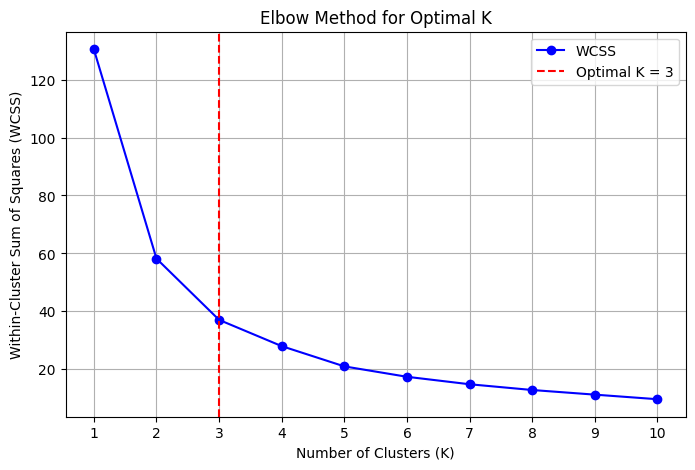

Optimal number of clusters (K) found by the Elbow Method: 3


In [10]:
# plot the Elbow MEthod graph
plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, marker='o', linestyle='-', color='blue', label='WCSS')
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal K = {optimal_k}')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal K')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()
print(f"Optimal number of clusters (K) found by the Elbow Method: {optimal_k}")

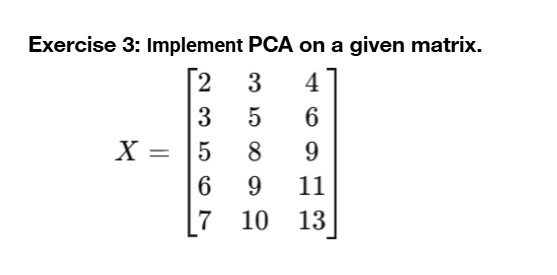

In [11]:
import numpy as np

In [12]:
# Step 1
X = np.array([
    [2,3,4],
    [3,5,6],
    [5,8,9],
    [6,9,11],
    [7,10,13]
])
X

array([[ 2,  3,  4],
       [ 3,  5,  6],
       [ 5,  8,  9],
       [ 6,  9, 11],
       [ 7, 10, 13]])

In [13]:
# Step 2 : Compute mean value for each column
mean_X = np.mean(X,axis=0)
print(mean_X)

[4.6 7.  8.6]


In [14]:
# Step 3 : Center the data
X_centered = X - mean_X
print(X_centered)

[[-2.6 -4.  -4.6]
 [-1.6 -2.  -2.6]
 [ 0.4  1.   0.4]
 [ 1.4  2.   2.4]
 [ 2.4  3.   4.4]]


In [15]:
# Step 4 : Compute the covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)
print(cov_matrix)

[[ 4.3   6.    7.55]
 [ 6.    8.5  10.5 ]
 [ 7.55 10.5  13.3 ]]


In [16]:
# Step 5 : Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print(eigenvalues)

[2.59637803e+01 5.52557327e-03 1.30694106e-01]


In [17]:
print(eigenvectors)

[[ 0.4066816   0.90812885  0.09955937]
 [ 0.56930735 -0.16669075 -0.80504865]
 [ 0.71449228 -0.38407836  0.58479449]]


In [18]:
# Step 6 : Select principal components (Sorting by largest eigenvalues)
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:,sorted_indices]

In [19]:
# Step 7 : Transform the Data
# 3 to 1 (Project onto first principal compnent)
X_transformed_1 = X_centered @eigenvectors[:,0]

In [20]:
# 3 to 2 
X_transformed_2 = X_centered @eigenvectors[:,:2]

In [21]:
# Output results
print("Tranformed Data (3 to 1): ")
print(X_transformed_1)
print("\nTranformed Data (3 to 2): ")
print(X_transformed_2)

Tranformed Data (3 to 1): 
[-6.62126605 -3.64698519  1.0177769   3.42275041  5.82772392]

Tranformed Data (3 to 2): 
[[-6.62126605  0.27128556]
 [-3.64698519 -0.06966338]
 [ 1.0177769  -0.5313071 ]
 [ 3.42275041 -0.0672074 ]
 [ 5.82772392  0.39689231]]


Dataset : Wine Quality

Exerise 4 : Implement PCA with Wine Quality Dataset 

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [23]:
df = pd.read_csv('winequality-red.csv')

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1596 entries, 0 to 1595
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1596 non-null   float64
 1   volatile acidity      1596 non-null   float64
 2   citric acid           1596 non-null   float64
 3   residual sugar        1596 non-null   float64
 4   chlorides             1596 non-null   float64
 5   free sulfur dioxide   1596 non-null   float64
 6   total sulfur dioxide  1596 non-null   float64
 7   density               1596 non-null   float64
 8   pH                    1596 non-null   float64
 9   sulphates             1596 non-null   float64
 10  alcohol               1596 non-null   float64
 11  quality               1596 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 149.8 KB


In [25]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [26]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [27]:
df['quality'].unique()

array([5, 6, 7, 4, 8, 3])

In [28]:
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [30]:
# Feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
# Apply PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=7)
X_train = pca.fit_transform(X_train)

In [32]:
X_test = pca.transform(X_test)

In [33]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=0)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [34]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = model.predict(X_test)

In [35]:
matrix = confusion_matrix(y_test, y_pred)
print(matrix)

[[ 0  1  0  0  0  0]
 [ 0  0  5  5  0  0]
 [ 0  0 95 36  0  0]
 [ 0  0 56 72 15  0]
 [ 0  0  3 24  7  0]
 [ 0  0  0  1  0  0]]


In [36]:
print("Accuracy : ", accuracy_score(y_test,y_pred)*100)

Accuracy :  54.37499999999999


In [37]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.60      0.73      0.66       131
           6       0.52      0.50      0.51       143
           7       0.32      0.21      0.25        34
           8       0.00      0.00      0.00         1

    accuracy                           0.54       320
   macro avg       0.24      0.24      0.24       320
weighted avg       0.51      0.54      0.52       320



C:\Users\Vruti\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Vruti\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Vruti\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_clas


**Exercise 2: Implement K-Medoids clustering on iris dataset using pyclustering.**

Load Iris dataset.

Select initial medoids randomly.

Apply K-Medoids clustering using pyclustering.

Assign data points to nearest medoids.

Update medoids iteratively.

Analyze final clusters and medoids.

Compare K-Medoids results with K-Means clustering.

In [38]:
# pip install pyclustering

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [43]:
pip install pyclustering

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
     ---- ----------------------------------- 0.3/2.6 MB ? eta -:--:--
     ---------------- ----------------------- 1.0/2.6 MB 3.4 MB/s eta 0:00:01
     ---------------- ----------------------- 1.0/2.6 MB 3.4 MB/s eta 0:00:01
     -------------------- ------------------- 1.3/2.6 MB 1.9 MB/s eta 0:00:01
     ------------------------ --------------- 1.6/2.6 MB 1.5 MB/s eta 0:00:01
     ------------------------ --------------- 1.6/2.6 MB 1.5 MB/s eta 0:00:01
     ---------------------------- ----------- 1.8/2.6 MB 1.4 MB/s eta 0:00:01
     ------------------------------------ --- 2.4/2.6 MB 1.4 MB/s eta 0:00:01
     ------------------------------------ --- 2.4/2.6 MB 1.4 MB/s eta 0:00:01
     ---------------------------------------- 2.6/2.6 MB 1.3 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: fini


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Vruti\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [44]:
from pyclustering.cluster.kmedoids import kmedoids
from pyclustering.utils import distance_metric, type_metric
from sklearn import datasets
from sklearn.preprocessing import StandardScaler

In [45]:
# Load the wine dataset
wine = datasets.load_wine()

In [46]:
# Convert the data into a pandas DataFrame for better readability
wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)

In [47]:
wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [48]:
wine_df.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')

In [49]:
wine_df.isna().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

In [ ]:
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
print(wine_df)

     alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0      14.23        1.71  2.43               15.6      127.0           2.80   
1      13.20        1.78  2.14               11.2      100.0           2.65   
2      13.16        2.36  2.67               18.6      101.0           2.80   
3      14.37        1.95  2.50               16.8      113.0           3.85   
4      13.24        2.59  2.87               21.0      118.0           2.80   
..       ...         ...   ...                ...        ...            ...   
173    13.71        5.65  2.45               20.5       95.0           1.68   
174    13.40        3.91  2.48               23.0      102.0           1.80   
175    13.27        4.28  2.26               20.0      120.0           1.59   
176    13.17        2.59  2.37               20.0      120.0           1.65   
177    14.13        4.10  2.74               24.5       96.0           2.05   

     flavanoids  nonflavanoid_phenols  proanthocyan

In [51]:
# Standarize the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(wine.data)

In [50]:
# Initial medoids(can be randomly chosen or specified)
# Here we choose the first three data points as initial medoids
initial_medoids = [0,1,2]

Randomly select initial medoids

Choose 3 random indices from the dataset

import random

initial_medoids = random.sample(range(len(X_scaled)),3)

In [ ]:
# Create the K-Medoids instance
metric = distance_metric(type_metric.EUCLIDEAN) # Euclidean distance
kmedoids_instance = kmedoids(X_scaled, initial_medoids, metric=metric)

In [54]:
# Perform the clustering
kmedoids_instance.process()

In [56]:
#get the resulting clusters and methods
clusters = kmedoids_instance.get_clusters()
medoids =kmedoids_instance.get_medoids()
print(clusters)

[[83, 96, 122, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177], [59, 60, 61, 62, 64, 66, 67, 68, 70, 72, 75, 76, 77, 78, 80, 81, 82, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 97, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 111, 112, 113, 114, 115, 116, 117, 118, 119, 123, 125, 126, 127, 128, 129], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 63, 65, 69, 71, 73, 74, 79, 95, 98, 109, 110, 120, 121, 124]]


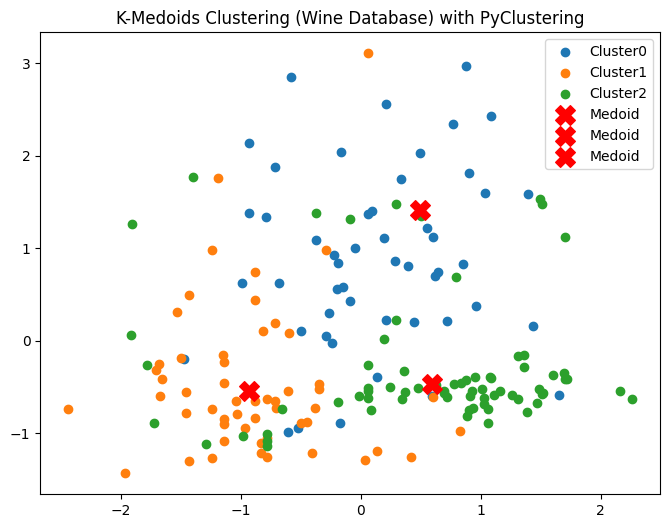

In [58]:
# Plot the results
plt.figure(figsize=(8,6))
for cluster in clusters:
    plt.scatter(X_scaled[cluster,0],
                X_scaled[cluster,1], label = f'Cluster{clusters.index(cluster)}')
    
# Mark the medoids in red
for medoid in medoids:
    plt.scatter(X_scaled[medoid,0],
                X_scaled[medoid,1], s=200, c='red', 
                marker='X', label='Medoid')

plt.title("K-Medoids Clustering (Wine Database) with PyClustering")
plt.legend()